# Greitzer's model 3DOF linearized
In this notebook we will present a linearized stability analysis of the Greitzer's Surge model (3D). Contrary to 2DOF analysis, this model doesn't neglect the influence of the G parameter on the stability of the system, leading to a stability map function of $B$ and $G$

## Import statements

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.optimize import fsolve

## plots configurations

In [74]:
plt.rc('text', usetex=False)      
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rcParams['font.size'] = 14
format_fig = (8, 5)

## Parameters set
this set of parameters leads to a stable configuration

In [75]:
N = 20e3                                    # [rpm] --> large N enlarges the cirle
r_ref = 100e-3                              # radius [m]
omega = 2*np.pi*N/60                        # [rad/s]
U_ref = omega*r_ref                         # reference speed of compressor[m/s]
a = 340                                     # speed of sound [m/s]
Vp = 0.0002                                 # plenum volume stable [m3]
dc = 10e-3                                  # inlet diameter [m]
Ac = (np.pi*dc**2)/4                        # inlet area [m2]
Lc = 0.1                                    # inlet length [m]
dt = 10e-3                                  # throttle diameter [m]
At = (np.pi*dt**2)/4                        # throttle area [m2]
Lt = 0.1                                    # throttle length [m]
B_real = (U_ref/(2*a))*np.sqrt(Vp/(Ac*Lc))  # B parameter of the described compressor
G_real = Lt*Ac/(Lc*At)                      # G parameter of the described compressor
k_valve = 2.7                               # 2.85 is unstable, 2.8 is stable. depends of course on parameters

## Compressor and throttle valve models
the compressor is modeled with a cubic interpolation of data points, while the throttle valve characteristic as a quadratic function of the mass flow rate

In [76]:
#compressor working points
phi_p = np.array([0.2, 0.4, 0.5, 0.6, 0.8])
psi_p = np.array([0.5, 0.8, 0.95, 1.0, 0.8])

#polynomial interpolation for the compressor curve
z_coeff = np.polyfit(phi_p, psi_p, 3)
phi = np.linspace(0, 1, 100)
psi_c = np.polyval(z_coeff, phi)

#throttle valve curve
psi_v = k_valve*phi**2

## equilibrium point
find the equilibrium point of the system as an intersection between the compressor and valve curves

In [77]:
#function that is zero at equilibrium point
def func_work_coefficient(phi):
    return np.polyval(z_coeff, phi) - k_valve*phi**2


initial_phi_guess = 0.9
phi_eq = fsolve(func_work_coefficient, initial_phi_guess)
psi_eq = k_valve * phi_eq ** 2

#calculate derivatives of the compressor and throttle characteristic at equilibrium point
delta_phi = phi_eq*0.001
phi_left = phi_eq - delta_phi
phi_right = phi_eq + delta_phi
psi_c_right = np.polyval(z_coeff,phi_right)
psi_c_left = np.polyval(z_coeff,phi_left)
psi_c_prime = (psi_c_right - psi_c_left) / (2*delta_phi)
psi_v_prime = 2*k_valve*phi_eq

## plot the compressor curve

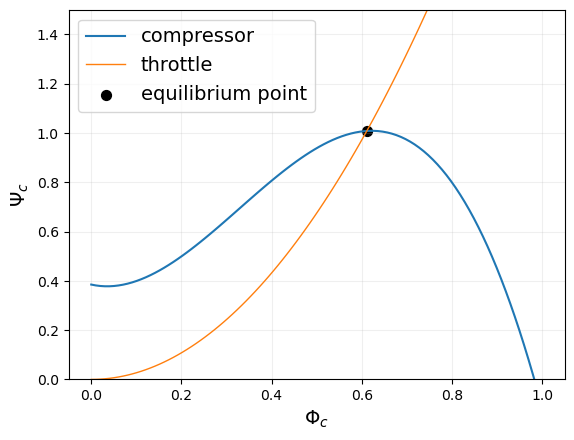

In [90]:
plt.figure()
plt.plot(phi, psi_c, label='compressor')
plt.plot(phi, psi_v,linewidth=1, label='throttle')
plt.scatter(phi_eq, psi_eq, color='black', s=50, label='equilibrium point')
plt.ylabel(r'$\Psi_c$')
plt.xlabel(r'$\Phi_c$')
plt.legend()
plt.ylim(0, 1.5)
plt.grid(alpha=0.2)

## solve the governing equations
the three governing equations are defined in Greitzer function in non-dimensional form. The initial condition (small with respect to the equilibrium values) is prescribed in y0.

In [79]:
def Greitzer(y, t, B, G, k_valve):
    """
    Defines the differential equations for the Greitzer model
    (as found in the thesis of Sündstrom).

    Arguments:
        y :  vector of the state variables
        t :  time
        B :  B parameter
        G :  G parameter
        
    State variables:
        x1 : compressor flow coefficient disturbance
        x2 : throttle flow coefficient disturbance
        x3 : plenum work coefficient disturbance
    """
    x1, x2, x3 = y
    dydt = [B*(psi_c_prime*x1-x3),
            (-psi_v_prime*x2+x3) * B/G,
            (x1-x2)/B]
    return dydt


t = np.linspace(0,100,5000) #temporal span

#initial conditions
y0 = [-0.01*phi_eq[0], 
      0.01*phi_eq[0], 
      -0.005*psi_eq[0]] 

#initial perturbations
IC_flow_c = [y0[0]]
IC_flow_t = [y0[1]]
IC_psi = [y0[2]]

#initial absolute values
IC_flow_c_abs = [phi_eq[0]+y0[0]]
IC_flow_t_abs = [phi_eq[0]+y0[1]]
IC_psi_abs = [psi_eq[0]+y0[2]]


from scipy.integrate import odeint
sol = odeint(Greitzer, y0, t, args=(B_real, G_real, k_valve))
initialDerivative = Greitzer(y0, t[0], B_real, G_real, k_valve)

## pictures folder
create the picture folder, in the path wanted

In [80]:
path = "pics/stable_case"
isExist = os.path.exists(path)
if not isExist:
   os.makedirs(path)

## plot the temporal evolution of the perturbation states

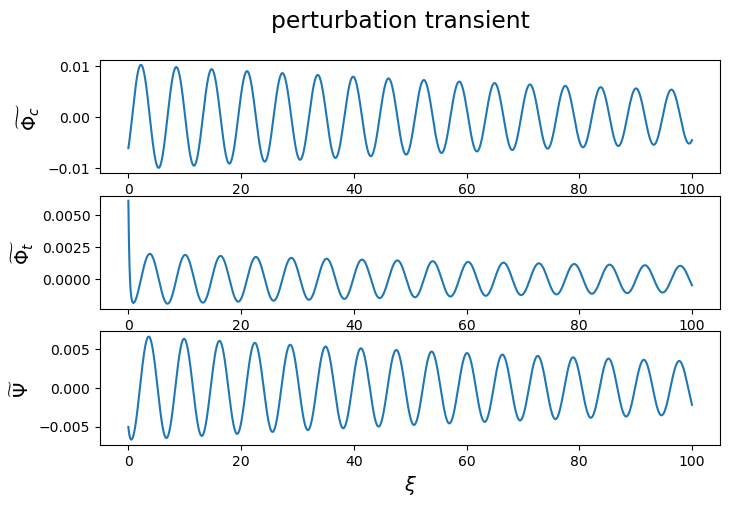

In [81]:
fig, axes = plt.subplots(3,1, figsize=format_fig)
axes[0].set_ylabel(r'$\widetilde{\Phi_{c}}$')
axes[0].plot(t,sol[:,0])
axes[1].set_ylabel(r'$\widetilde{\Phi_{t}}$')
axes[1].plot(t,sol[:,1])
axes[2].set_ylabel(r'$\widetilde{\Psi}$')
axes[2].plot(t,sol[:,2])
axes[2].set_xlabel(r'$\xi $')
fig.suptitle('perturbation transient')
fig.savefig(path+'/perturbation_transient.pdf', bbox_inches='tight')

## plot the perturbations in the phase space
plot simply how the the pressure increase changes as a function of the compressor mass flow rate. The other combinations are similar

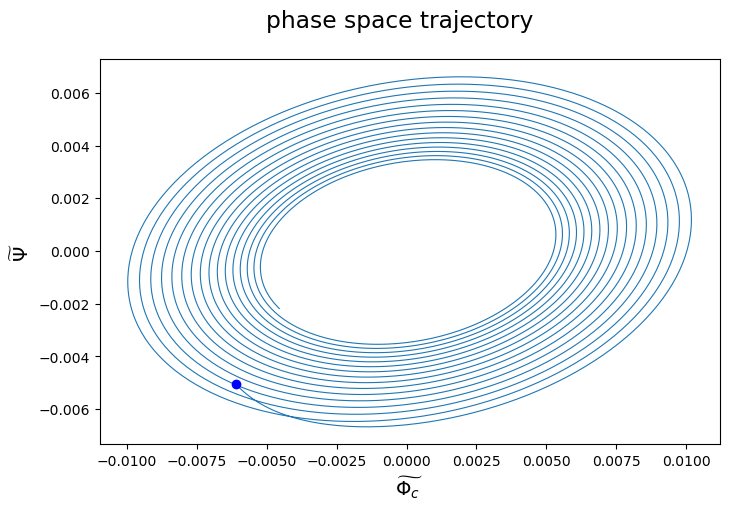

In [82]:
fig, axes = plt.subplots(figsize=format_fig)
axes.set_ylabel(r'$\widetilde{\Psi}$')
axes.set_xlabel(r'$\widetilde{\Phi_{c}}$')
axes.plot(sol[:, 0],sol[:, 2],linewidth=0.8)
axes.plot(IC_flow_c, IC_psi, marker='o', color='b', label='IC')
fig.suptitle('phase space trajectory')
fig.savefig(path+'/phase_space_perturbations.pdf', bbox_inches='tight')

## compute the stability map

In [83]:
# discretisation
grid_num = 100

# domain of research
B_min = 0.001
B_max = 2
G_min = 0.001
G_max = 3
B = np.linspace(B_min,B_max,grid_num)
G = np.linspace(G_min,G_max,grid_num)
B_grid, G_grid = np.meshgrid(B,G)

stability = np.zeros((grid_num,grid_num), dtype=float)
for i in range(len(B)):
    for j in range(len(G)):
        B_r = B_grid[i,j]
        G_r = G_grid[i,j]
        coeffs = [-1, 
                  B_r*psi_c_prime-B_r*psi_v_prime/G_r,
                  (psi_c_prime*psi_v_prime*B_r**2)/G_r - 1/G_r -1, 
                  (B_r/G_r)*(psi_c_prime-psi_v_prime)]
        
        # Find the roots of the polynomial
        roots = np.roots(coeffs)
        roots_real = roots.real

        if (roots_real[0]>=0 or roots_real[1]>=0 or roots_real[2]>=0):
            stability[i,j] = 1.0 #unstable
        else:
            stability[i,j] = -1.0 #stable

/Users/fneri/anaconda3/lib/python3.10/site-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


## plot the stability map

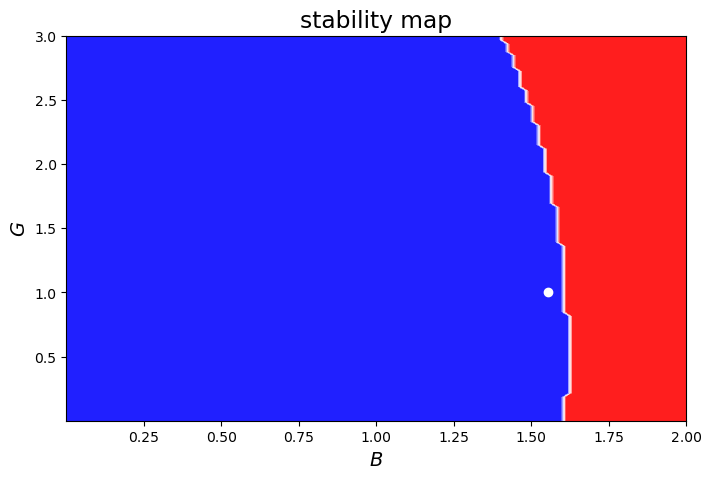

In [84]:
plt.figure(figsize=format_fig)
plt.contourf(B_grid, G_grid, stability, cmap='bwr')
plt.plot(B_real, G_real, 'ow')
plt.xlabel(r'$B$')
plt.ylabel(r'$G$')
plt.title('stability map')
plt.savefig(path+'/stability_map.pdf', bbox_inches='tight')
